# Supervised learning Capstone Project

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../../jupyter_notebooks/DATA/Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Exploratory Data Analysis
Confirm that there are no NaN cells

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

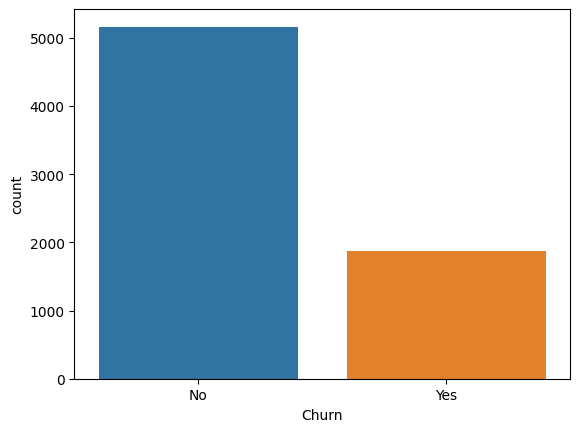

In [7]:
sns.countplot(data=df, x='Churn',hue='Churn')

<Axes: xlabel='Churn', ylabel='TotalCharges'>

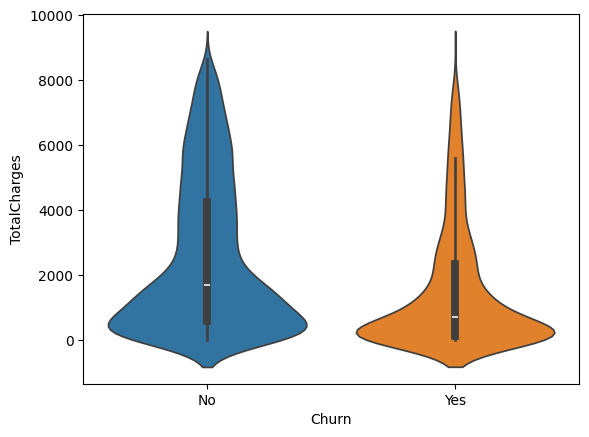

In [8]:
sns.violinplot(data=df,x='Churn',y='TotalCharges', hue='Churn')

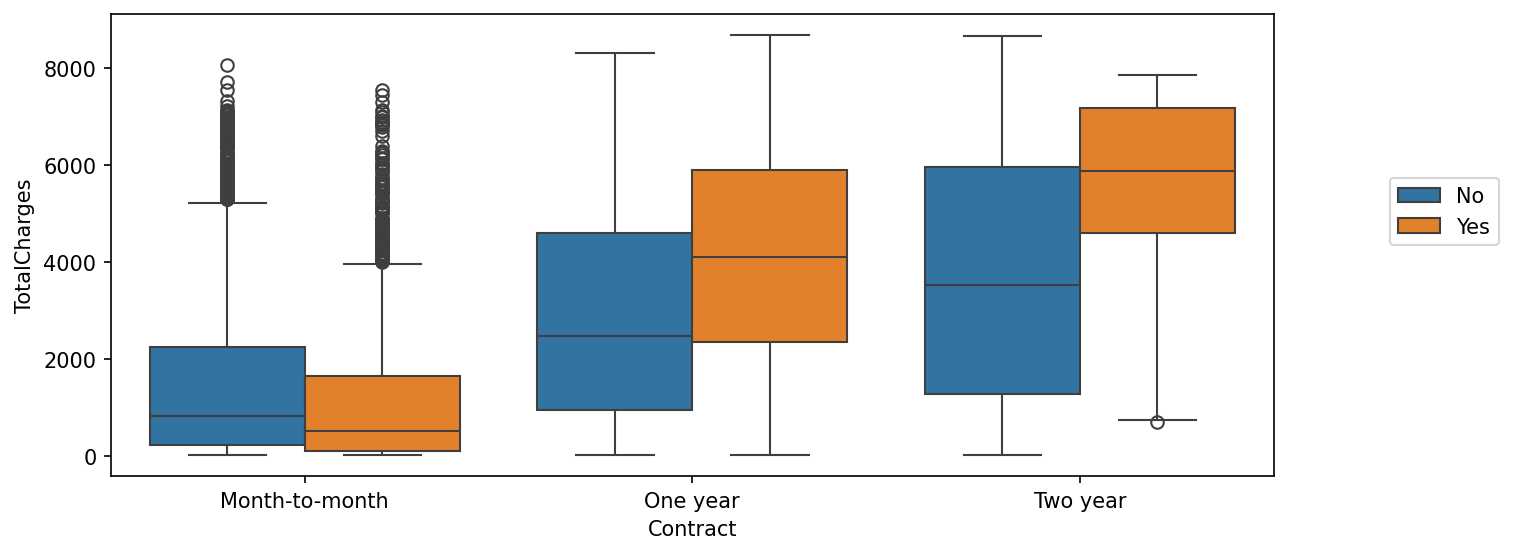

In [154]:
plt.figure(figsize=(10,4),dpi=150)
sns.boxplot(data=df,x='Contract',y='TotalCharges',hue='Churn')
plt.legend(loc=(1.1,0.5))

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [11]:
df_dum=pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Churn']])

In [12]:
df_dum.columns

Index(['SeniorCitizen', 'gender_Female', 'gender_Male', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes',
     

In [13]:
correlations=df_dum.corr()
sort_corr=correlations['Churn_Yes'].sort_values().iloc[1:-1]

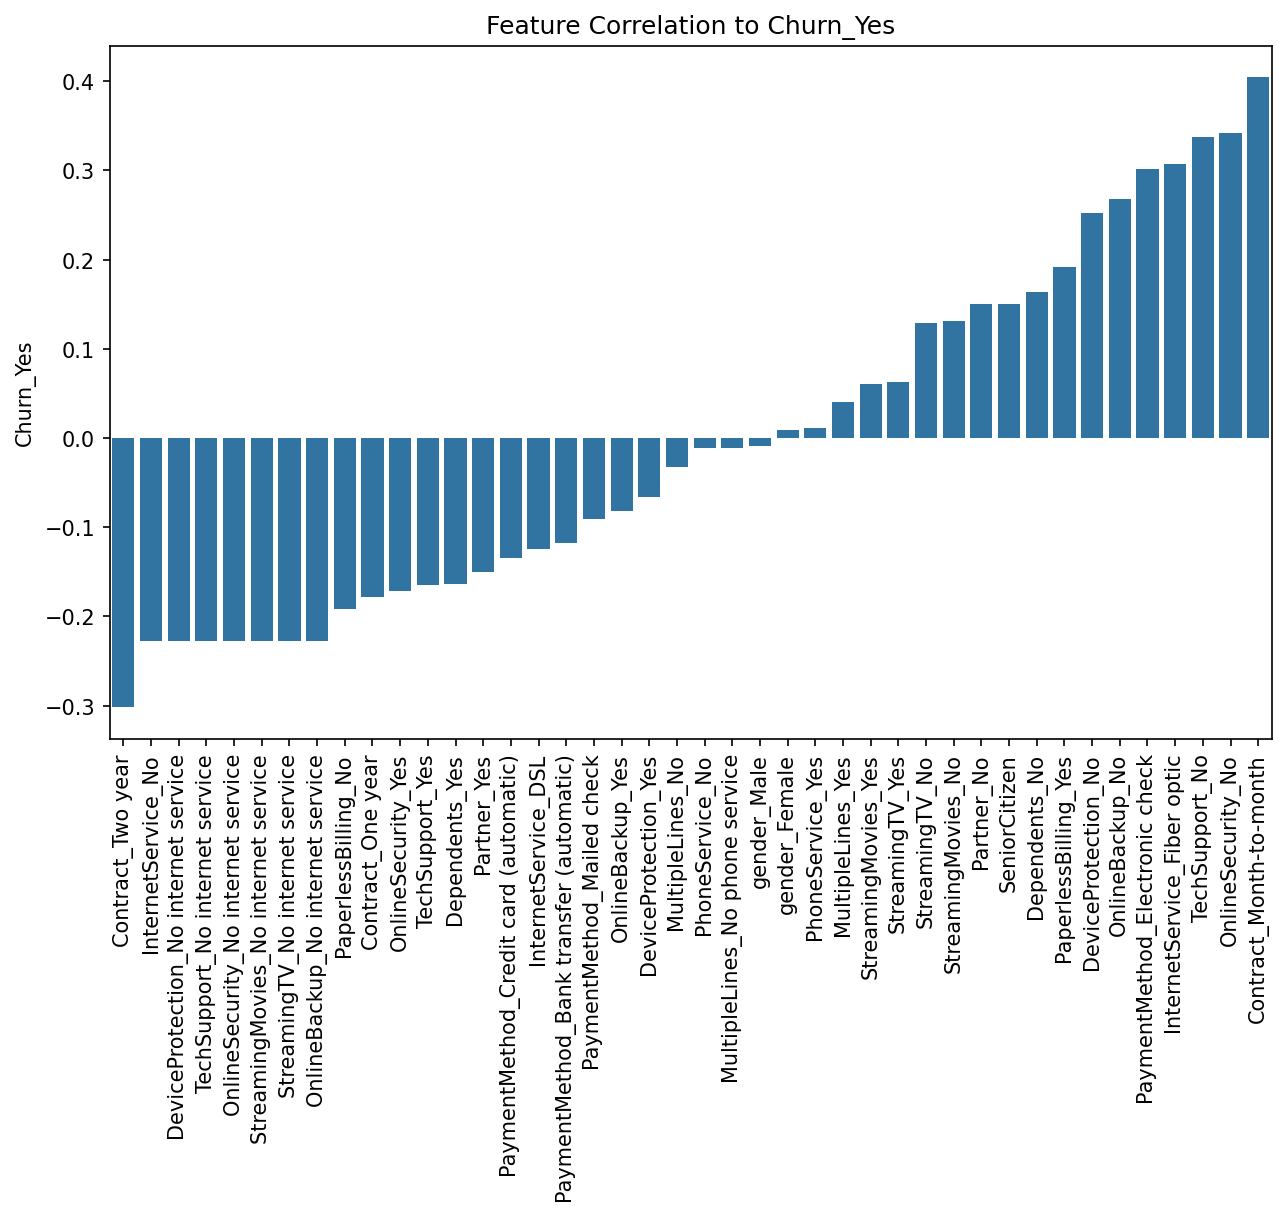

In [14]:
plt.figure(figsize=(10,6),dpi=150)
sns.barplot(sort_corr)
plt.title('Feature Correlation to Churn_Yes')
plt.xticks(rotation=90);

## Part 3: Churn Analysis

In [15]:
# Different types of contract
df['Contract'].unique()

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

<Axes: xlabel='tenure', ylabel='Count'>

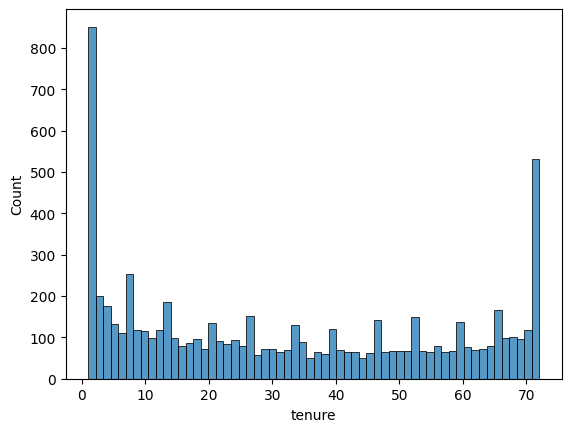

In [155]:
sns.histplot(data=df,x='tenure',bins=60)

([<matplotlib.axis.XTick at 0x2158e53d310>,
 [Text(-1, 0, ''),
  Text(9, 0, '10'),
  Text(19, 0, '20'),
  Text(29, 0, '30'),
  Text(39, 0, '40'),
  Text(49, 0, '50'),
  Text(59, 0, '60'),
  Text(69, 0, '70')])

<Figure size 1000x600 with 0 Axes>

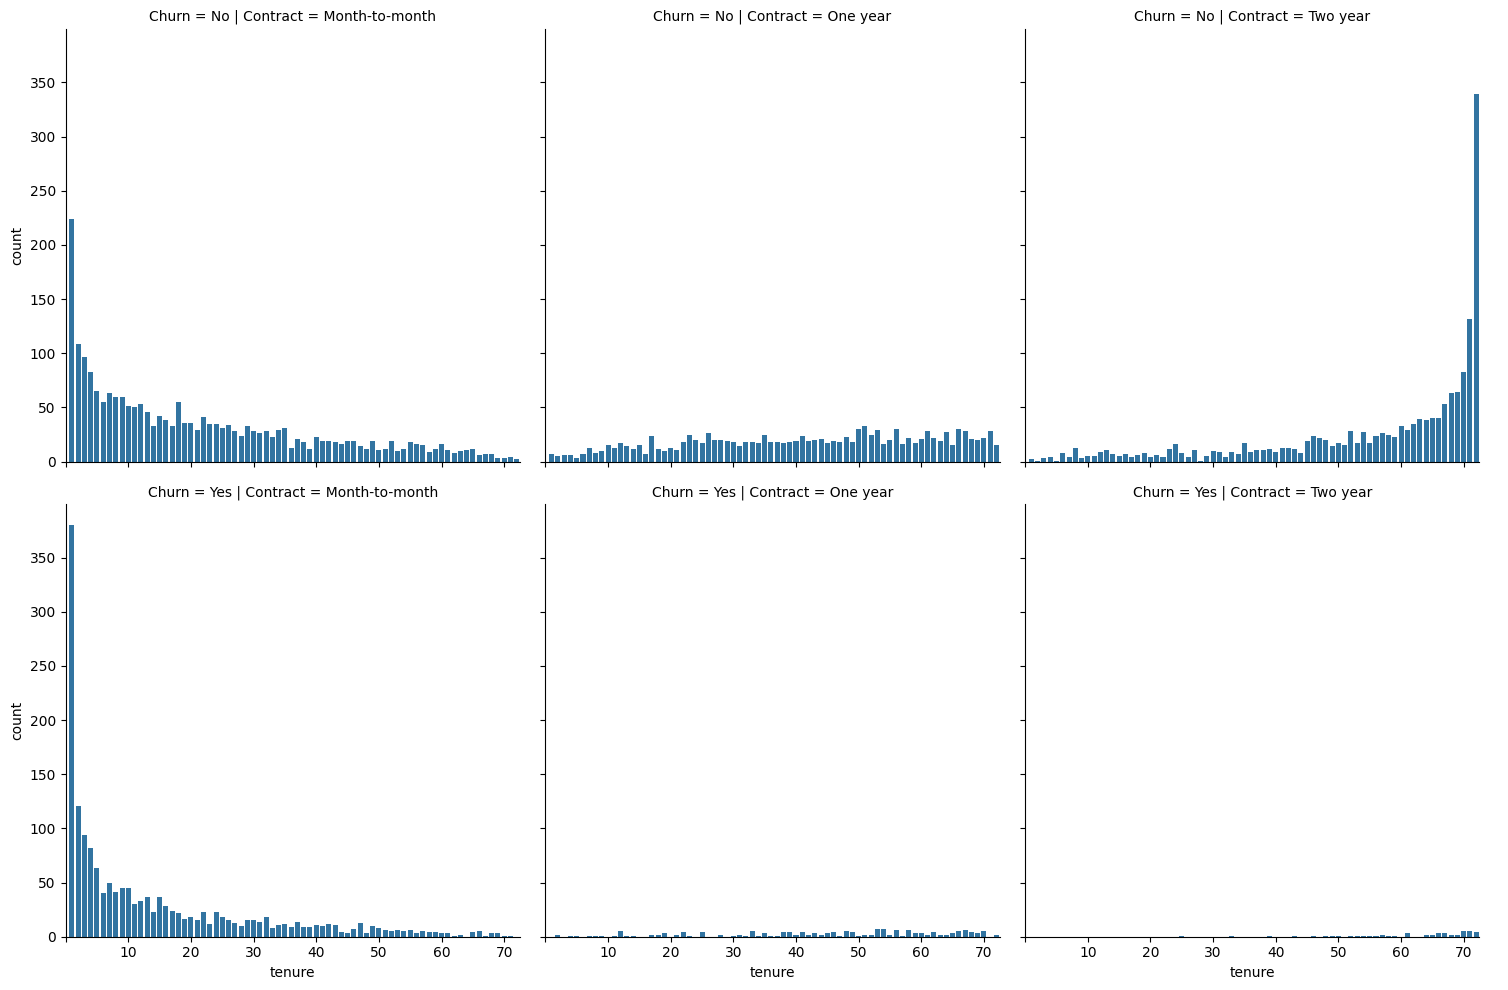

In [17]:
plt.figure(figsize=(10,6))
sns.catplot(data=df,x='tenure',kind='count',row='Churn',col='Contract');
#sns.catplot
plt.xticks(np.arange(-1,70,10))

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

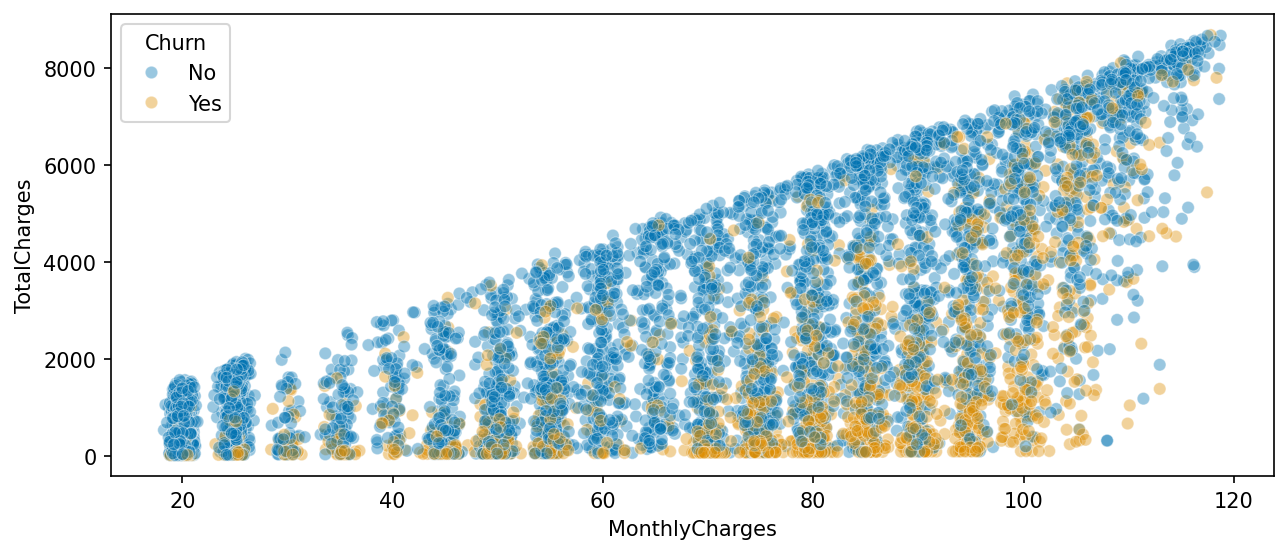

In [18]:
plt.figure(figsize=(10,4),dpi=150)
sns.scatterplot(data=df,y='TotalCharges',x='MonthlyCharges',hue='Churn',palette='colorblind',alpha=0.4)

In [19]:
#Tenure goes from 1 to 72 months. For each tenure length, calculate the churn %
churnbymonth=df[['Churn','tenure','customerID']].groupby(['Churn','tenure']).count()
monthly_churn=churnbymonth['customerID']['Yes']/(churnbymonth['customerID']['No'] + churnbymonth['customerID']['Yes'])*100
monthly_churn

tenure
1     61.990212
2     51.680672
3     47.000000
4     47.159091
5     48.120301
        ...    
68     9.000000
69     8.421053
70     9.243697
71     3.529412
72     1.657459
Name: customerID, Length: 72, dtype: float64

<Axes: xlabel='tenure', ylabel='Churn Percentage'>

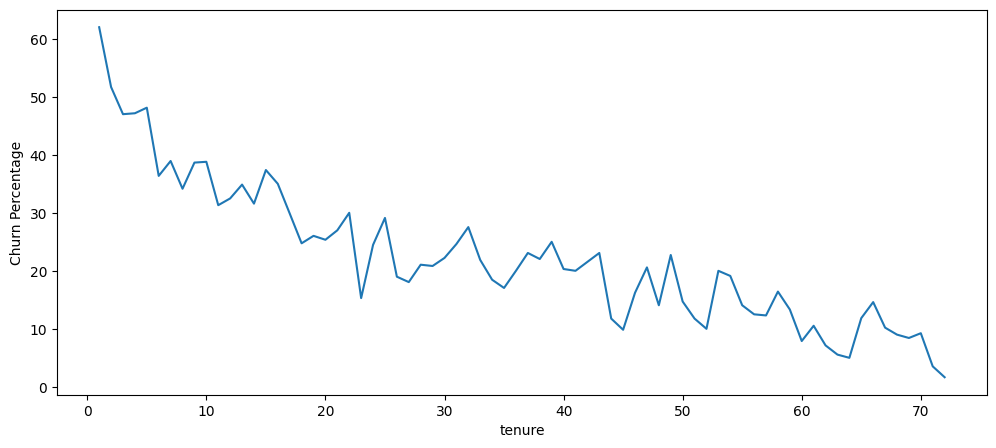

In [20]:
#Plot churn versus tenure
monthly_churn.plot(xlabel='tenure',ylabel='Churn Percentage',figsize=(12,5))

In [21]:
#Create 'TenureCohort' column that tells how long in 12-months segments a customer has been a customer
# 0-12Months,13-24Months, . . . Over48Months

In [22]:
def tenure_cohort(months):
    years=int(months/12)
    if (years < 1): return '0-11Months'
    if (years < 2): return '12-24Months'
    if (years < 3): return '24-48Months'
    if (years < 4): return '24-48Months'
    return 'Over48Months'

In [23]:
df['TenureCohort']=(df['tenure']//12).map({0:'0-12Months',1:'12-24Months',2:'24-48Months',3:'24-48Months',4:'Over48Months',5:'Over48Months',6:'Over48Months'})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

In [24]:
df[['tenure','TenureCohort']]

,tenure,TenureCohort
0,1,0-12Months
1,34,24-48Months
2,2,0-12Months
3,45,24-48Months
4,2,0-12Months
...,...,...
7027,24,24-48Months
7028,72,Over48Months
7029,11,0-12Months
7030,4,0-12Months


In [25]:
df['TenureCohort'].value_counts()

TenureCohort
Over48Months    2303
0-12Months      2058
24-48Months     1624
12-24Months     1047
Name: count, dtype: int64

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

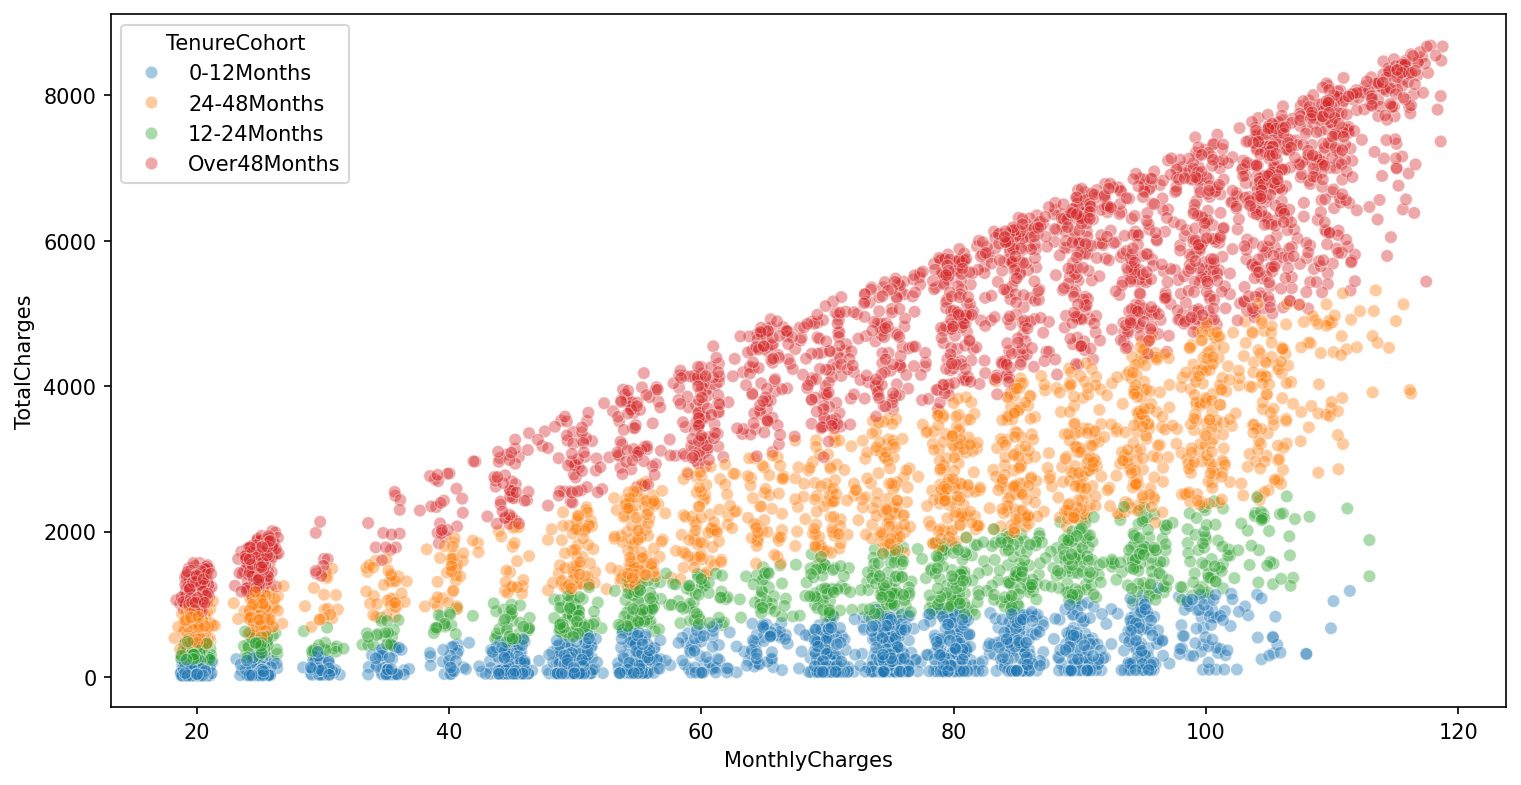

In [26]:
plt.figure(figsize=(12,6),dpi=150)
sns.scatterplot(data=df,x='MonthlyCharges',y='TotalCharges',hue='TenureCohort',alpha=0.4)

<Axes: xlabel='TenureCohort', ylabel='count'>

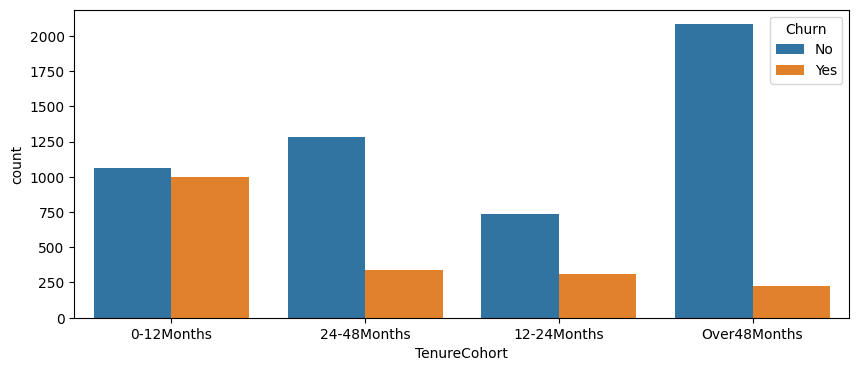

In [27]:
plt.figure(figsize=(10,4))
sns.countplot(data=df,x='TenureCohort',hue='Churn')

<Figure size 1500x900 with 0 Axes>

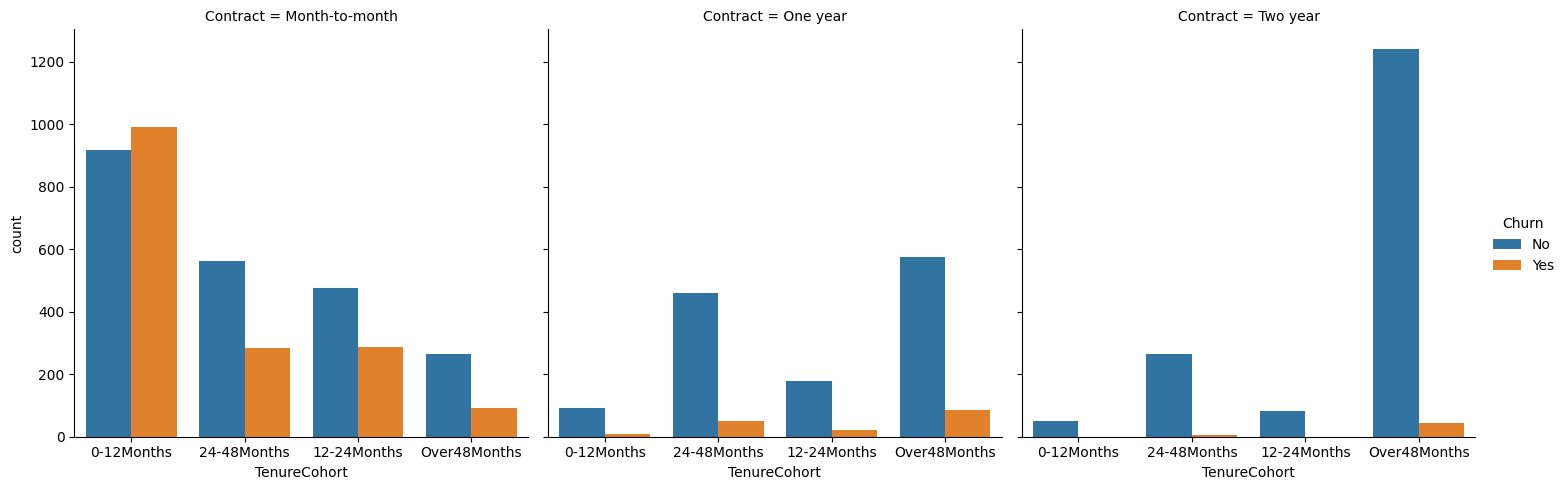

In [28]:
#Count plots to show churn depending on contract type.
plt.figure(figsize=(10,6),dpi=150)
sns.catplot(data=df,x='TenureCohort',col='Contract',hue='Churn',kind='count')

# Part 4: Predictive modeling

## Single Decision Tree

In [29]:
X=df.drop(['Churn','customerID'],axis=1)
X=pd.get_dummies(X,drop_first=True)
y=df['Churn']

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [32]:
dt=DecisionTreeClassifier()

In [33]:
param_grid={'criterion':['gini','entropy','log_loss'],'splitter':['best','random'],'max_depth':[2,4,5,6,8,10,15],'min_samples_split':[2,4,7,10,20],'min_samples_leaf':[1,2,3],'max_features':[1,3,6,15,20]}

In [34]:
grid=GridSearchCV(dt,param_grid,verbose=2)

In [35]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 3150 candidates, totalling 15750 fits
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=2, max_features=1, min_samples_leaf=1, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END criterion=gini, ma

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 4, ...], 'max_features': [1, 3, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

In [36]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 6,
 'max_features': 20,
 'min_samples_leaf': 3,
 'min_samples_split': 4,
 'splitter': 'best'}

# Best parameters
As per grid search:
{'criterion': 'log_loss',
 'max_depth': 5,
 'max_features': 15,
 'min_samples_leaf': 3,
 'min_samples_split': 4,
 'splitter': 'best'}

In [37]:
preds=grid.predict(X_test)

In [38]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

          No       0.88      0.85      0.87       557
         Yes       0.51      0.57      0.54       147

    accuracy                           0.80       704
   macro avg       0.70      0.71      0.70       704
weighted avg       0.81      0.80      0.80       704



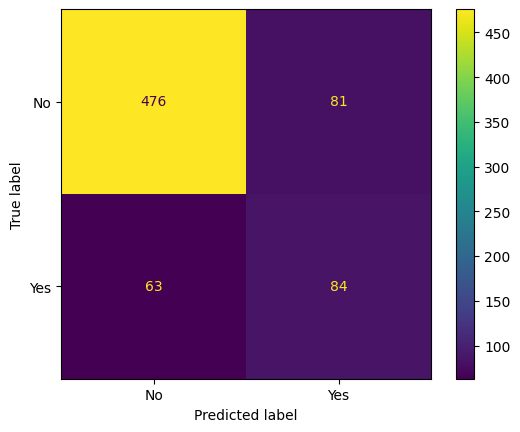

In [39]:
ConfusionMatrixDisplay.from_estimator(grid.best_estimator_,X_test,y_test)

In [40]:
from sklearn.tree import plot_tree

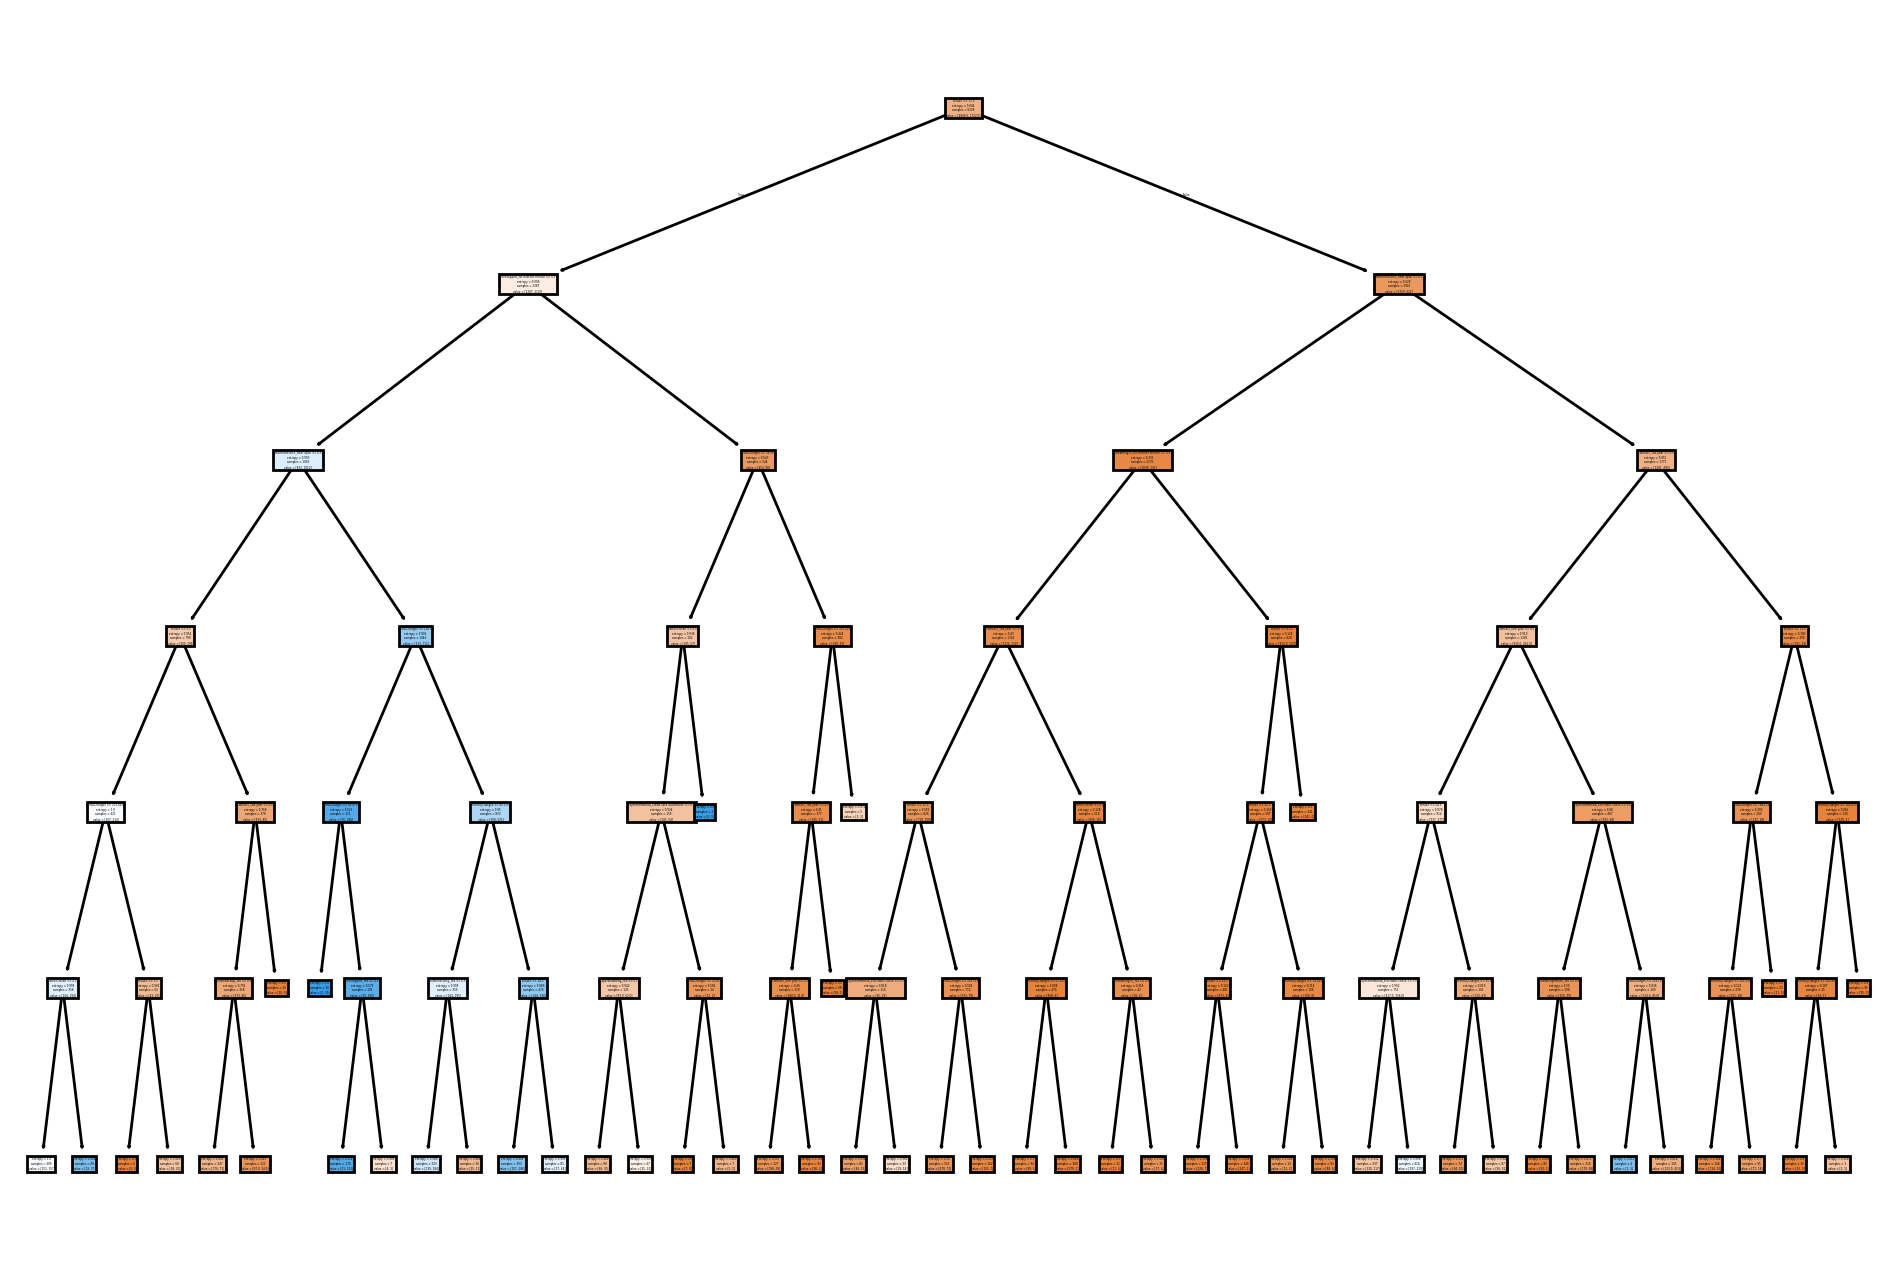

In [41]:
plt.figure(figsize=(12,8),dpi=200)
plot_tree(grid.best_estimator_,feature_names=X.columns,filled=True);

In [42]:
feat_import=pd.DataFrame(index=X.columns,data=grid.best_estimator_.feature_importances_,columns=['Importance'])
feat_import

,Importance
SeniorCitizen,0.010857
tenure,0.359372
MonthlyCharges,0.025872
TotalCharges,0.067258
gender_Male,0.000000
Partner_Yes,0.000000
Dependents_Yes,0.000000
PhoneService_Yes,0.000000
MultipleLines_No phone service,0.000000
MultipleLines_Yes,0.000000


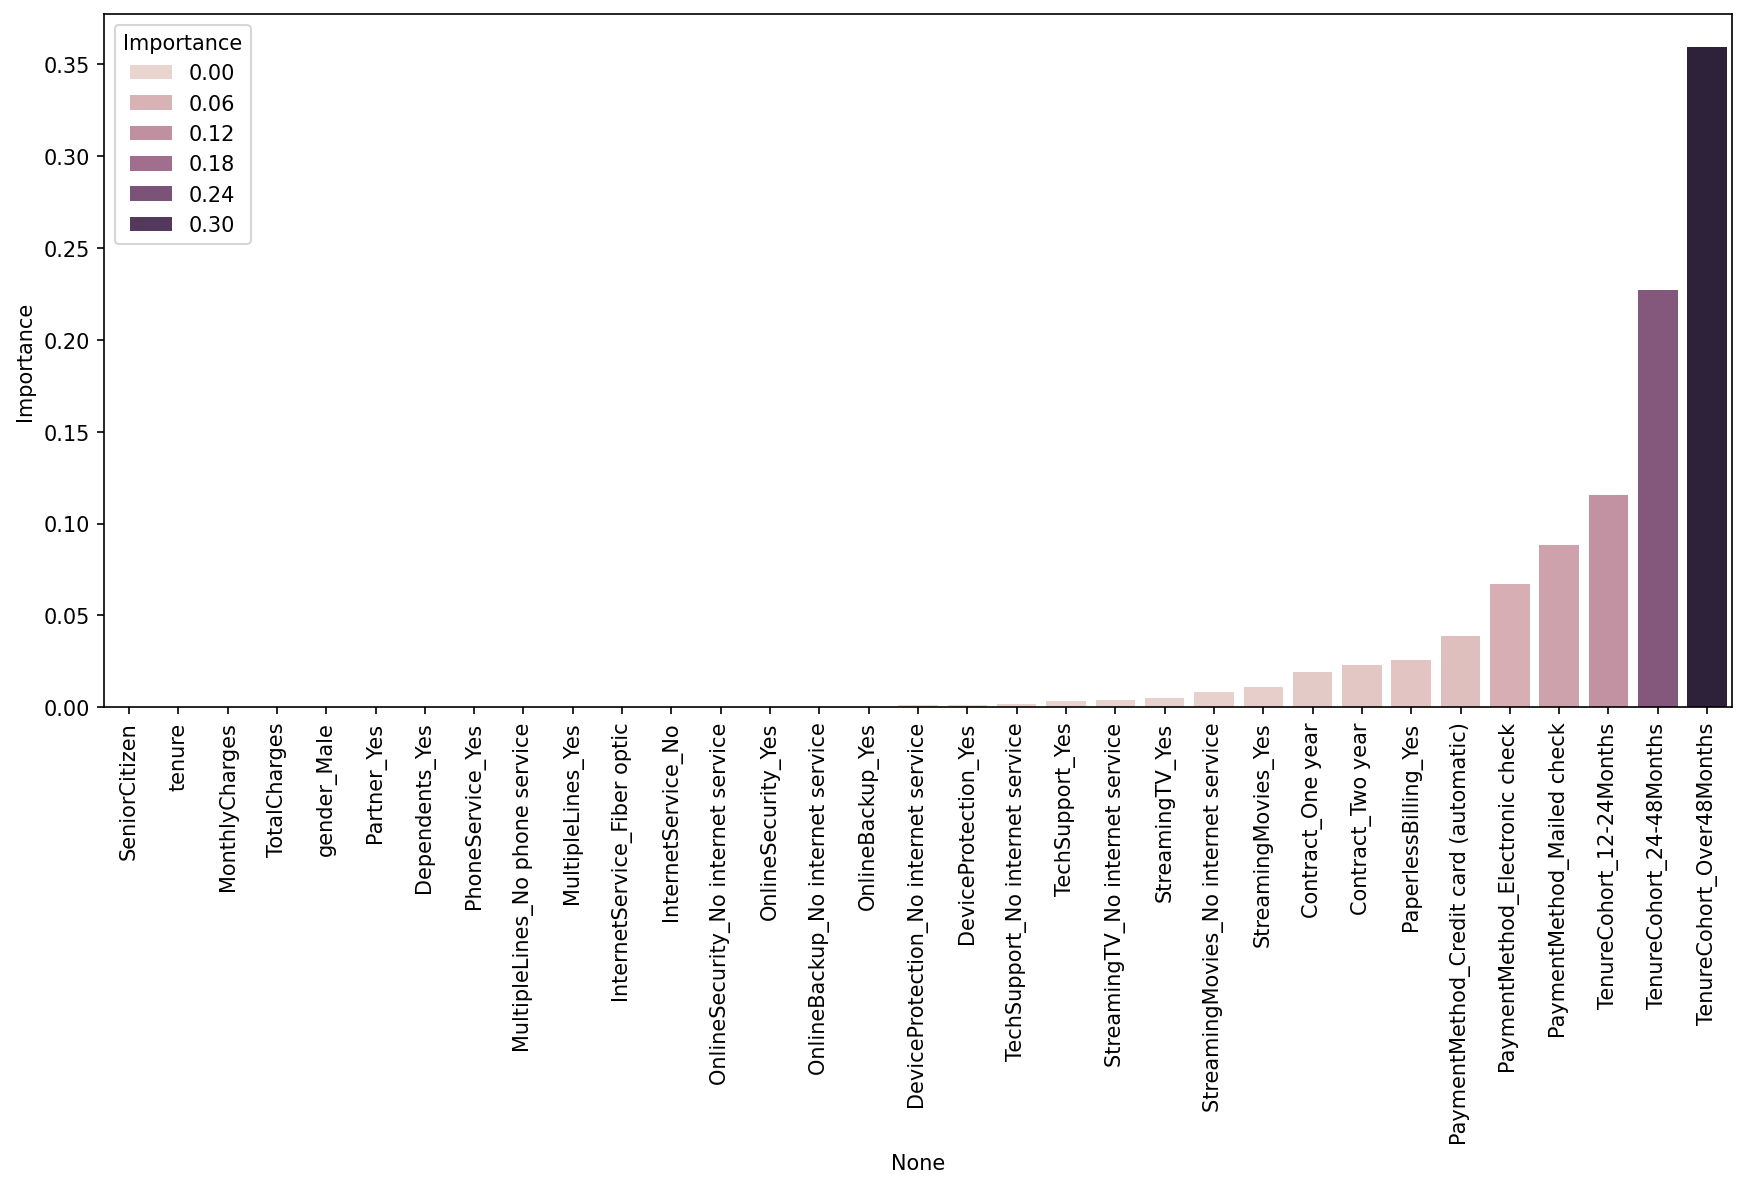

In [43]:
plt.figure(figsize=(14,6),dpi=150)
sns.barplot(data=feat_import.sort_values('Importance'),x=feat_import.index,y='Importance',hue='Importance');
plt.xticks(rotation=90);

## Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'TenureCohort'],
      dtype='str')

In [47]:
rf=RandomForestClassifier()

In [88]:
#rf_param_grid={'n_estimators':[25,50,75],'criterion':['gini','entropy','log_loss'],'max_depth':[6,8,10,],'min_samples_split':[2,4,7],'min_samples_leaf':[3,4,5],'max_features':[3,6,10]}
rf_param_grid={'criterion':['log_loss'],'max_depth':[10,12,14],'max_features':[3],'min_samples_leaf':[5,6,7],'min_samples_split':[2,3,4],'n_estimators':[75,100,125]}

In [89]:
rf_grid=GridSearchCV(rf,rf_param_grid,verbose=2)

In [90]:
rf_grid.fit(X_train,y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END criterion=log_loss, max_depth=10, max_features=3, min_samples_leaf=5, min_samples_split=2, n_estimators=75; total time=   0.4s
[CV] END criterion=log_loss, max_depth=10, max_features=3, min_samples_leaf=5, min_samples_split=2, n_estimators=75; total time=   0.4s
[CV] END criterion=log_loss, max_depth=10, max_features=3, min_samples_leaf=5, min_samples_split=2, n_estimators=75; total time=   0.3s
[CV] END criterion=log_loss, max_depth=10, max_features=3, min_samples_leaf=5, min_samples_split=2, n_estimators=75; total time=   0.4s
[CV] END criterion=log_loss, max_depth=10, max_features=3, min_samples_leaf=5, min_samples_split=2, n_estimators=75; total time=   0.3s
[CV] END criterion=log_loss, max_depth=10, max_features=3, min_samples_leaf=5, min_samples_split=2, n_estimators=100; total time=   0.6s
[CV] END criterion=log_loss, max_depth=10, max_features=3, min_samples_leaf=5, min_samples_split=2, n_estimators=100; tot

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['log_loss'], 'max_depth': [10, 12, ...], 'max_features': [3], 'min_samples_leaf': [5, 6, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

In [91]:
rf_grid.best_params_

{'criterion': 'log_loss',
 'max_depth': 10,
 'max_features': 3,
 'min_samples_leaf': 5,
 'min_samples_split': 2,
 'n_estimators': 100}

In [92]:
rf_model=rf_grid.best_estimator_

In [93]:
rf_preds=rf_model.predict(X_test)

In [94]:
print(classification_report(y_test,rf_preds))

              precision    recall  f1-score   support

          No       0.87      0.92      0.90       557
         Yes       0.62      0.48      0.54       147

    accuracy                           0.83       704
   macro avg       0.74      0.70      0.72       704
weighted avg       0.82      0.83      0.82       704



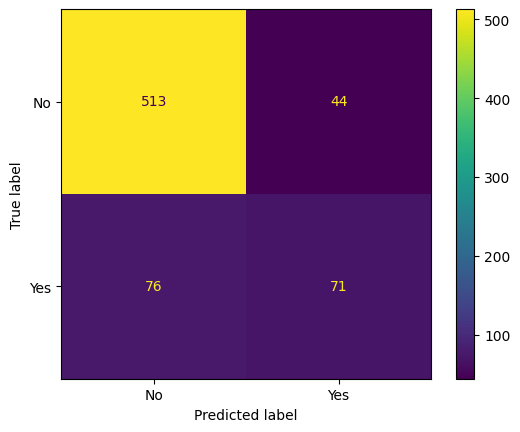

In [95]:
ConfusionMatrixDisplay.from_estimator(rf_model,X_test,y_test)

## Boosted trees

In [96]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [107]:
gb_param_grid={'n_estimators':[50,100,125],'learning_rate':[0.01,0.05,0.1,0.2],'max_depth':[1,3,4,5]}

In [108]:
gb_model=GradientBoostingClassifier()

In [110]:
gb_grid=GridSearchCV(gb_model,gb_param_grid,verbose=2)

In [111]:
gb_grid.fit(X_train,y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END ...learning_rate=0.01, max_depth=1, n_estimators=50; total time=   0.2s
[CV] END ...learning_rate=0.01, max_depth=1, n_estimators=50; total time=   0.2s
[CV] END ...learning_rate=0.01, max_depth=1, n_estimators=50; total time=   0.2s
[CV] END ...learning_rate=0.01, max_depth=1, n_estimators=50; total time=   0.2s
[CV] END ...learning_rate=0.01, max_depth=1, n_estimators=50; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=100; total time=   0.4s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=100; total time=   0.4s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=100; total time=   0.6s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=100; total time=   0.5s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=100; total time=   0.6s
[CV] END ..learning_rate=0.01, max_depth=1, n_estimators=125; total time=   0.6s
[CV] END ..learning_rate=0.01, max_depth=1, n_e

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [1, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [112]:
gb_grid.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

In [113]:
gb_model=gb_grid.best_estimator_

In [114]:
gb_preds=gb_model.predict(X_test)

In [115]:
print(classification_report(y_test,gb_preds))

              precision    recall  f1-score   support

          No       0.87      0.90      0.89       557
         Yes       0.58      0.50      0.54       147

    accuracy                           0.82       704
   macro avg       0.73      0.70      0.71       704
weighted avg       0.81      0.82      0.82       704



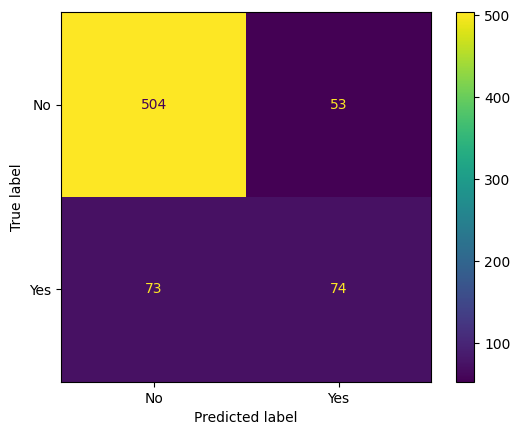

In [116]:
ConfusionMatrixDisplay.from_estimator(gb_model,X_test,y_test)

In [145]:
ab_model=AdaBoostClassifier()

In [146]:
ab_param_grid={'n_estimators':[125,150,200]}

In [147]:
ab_grid=GridSearchCV(ab_model,ab_param_grid,verbose=2)

In [148]:
ab_grid.fit(X_train,y_train)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[CV] END ...................................n_estimators=125; total time=   1.6s
[CV] END ...................................n_estimators=125; total time=   1.7s
[CV] END ...................................n_estimators=125; total time=   1.8s
[CV] END ...................................n_estimators=125; total time=   1.8s
[CV] END ...................................n_estimators=125; total time=   1.8s
[CV] END ...................................n_estimators=150; total time=   2.3s
[CV] END ...................................n_estimators=150; total time=   2.1s
[CV] END ...................................n_estimators=150; total time=   2.0s
[CV] END ...................................n_estimators=150; total time=   1.7s
[CV] END ...................................n_estimators=150; total time=   2.1s
[CV] END ...................................n_estimators=200; total time=   2.8s
[CV] END ...................................n_est

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_estimators': [125, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parame

In [149]:
ab_grid.best_params_

{'n_estimators': 200}

In [150]:
ab_model_end=ab_grid.best_estimator_

In [151]:
ab_preds=ab_model_end.predict(X_test)

In [152]:
print(classification_report(y_test,ab_preds))

              precision    recall  f1-score   support

          No       0.88      0.92      0.90       557
         Yes       0.62      0.50      0.55       147

    accuracy                           0.83       704
   macro avg       0.75      0.71      0.73       704
weighted avg       0.82      0.83      0.82       704



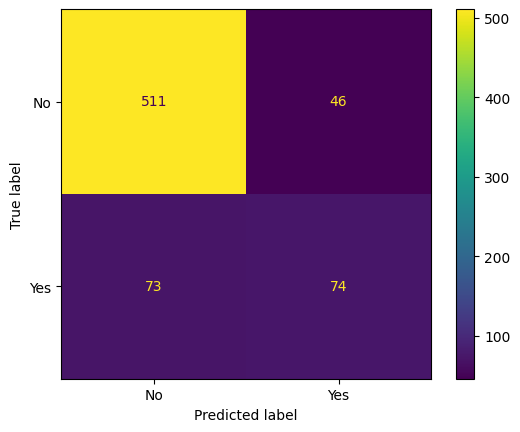

In [153]:
ConfusionMatrixDisplay.from_estimator(ab_model_end,X_test,y_test)